# P8 — Notebook 3 v2: Theorem 1 Empirical Validation (phase-aware)

**Goal**: empirically validate Theorem 1 using the **phase-aware** preservation
metric `rho_phase_k` from Notebook 1 v5, the DSSP profile `alpha_k` from
Notebook 2, and the 288-run detector F1 results.

**Theorem 1**: $|\Delta F_1|^2 \le C \cdot \sum_{k=1}^{K}\alpha_k(1-\rho_k)^2$

**v2 changes** (vs NB3 v1):
- Uses `rho_phase_k` (phase-aware, the Theorem 1 quantity) — not the energy `rho_k`.
- Adds **leave-one-σ-out cross-validation** of C — the honest predictive test
  (the post-hoc 0-violation count is tautological by construction).
- Phase A verification scope = **yolov8m × PnPLO** (the one detector with a
  measured α). Other detectors appear only as a flagged *exploratory* check
  (borrowed α — not a valid verification; cross-detector α is Phase B).
- Two figures only — theorem verification + ranking. The α / two-mode /
  cross-dataset figures are produced by Notebook 1 v5.

**Inputs**: 3 ρ CSVs (v5 schema, `rho_phase_k`), `alpha_profile_yolov8m_pnplo.yaml`,
`classification_metrics.csv`.


In [ ]:
# Cell 1: Setup + IEEE TIP figure style
import os, sys, time, yaml, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- IEEE TIP figure style: vector PDF, embedded serif fonts ---
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8,
    'legend.fontsize': 6.5, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.linewidth': 0.6, 'lines.linewidth': 1.0,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 600, 'savefig.bbox': 'tight',
})
COL1, COL2 = 3.5, 7.16
OI = {'orange': '#E69F00', 'sky': '#56B4E9', 'green': '#009E73',
      'blue': '#0072B2', 'verm': '#D55E00', 'purple': '#CC79A7'}
METHOD_LABEL = {'bm3d': 'BM3D', 'dncnn': 'DnCNN', 'autoencoder': 'AE',
                'cae_pso': 'CAE+PSO', 'gaussian_filter': 'Gaussian'}

def save_fig(fig, name):
    p = FIG_DIR / f'{name}.pdf'
    fig.savefig(p)
    print(f'  saved \u2192 {p}')
    plt.show()

# Mount Drive (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print('\u2713 Setup complete')


Mounted at /content/drive
✓ Setup complete


In [ ]:
# Cell 2: Config
DRIVE_ROOT = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT')

# Notebook 1 v5 outputs (v5 schema: includes rho_phase_k)
RHO_CSV_PATHS = {
    'PnPLO': DRIVE_ROOT / '04_RESULT_TRAIN_KARTHY/P8_outputs/rho_per_cell__PnPLO__phaseA__v1.csv',
    'VOC':   DRIVE_ROOT / '04_1_VOC_experiment/P8_outputs/rho_per_cell__VOC__phaseA__v1.csv',
    'INRIA': DRIVE_ROOT / '04_2_INRIA_experiment/P8_outputs/rho_per_cell__INRIA__phaseA__v1.csv',
}

# Notebook 2 output  (v2 FIX: path includes YOLO_Denoise_Experiment_Karthy/)
ALPHA_YAML_PATH = (DRIVE_ROOT / '04_RESULT_TRAIN_KARTHY' /
                   'YOLO_Denoise_Experiment_Karthy' / 'P8_outputs' /
                   'alpha_profile_yolov8m_pnplo.yaml')

# 288-run framework F1 results
F1_288_PATH = DRIVE_ROOT / '04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/ver_7/results_summary/classification_metrics.csv'

# Notebook 3 outputs — figures land in the shared paper_figures folder (= NB1 v5)
FIG_DIR = DRIVE_ROOT / 'P8_outputs' / 'paper_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_YAML = DRIVE_ROOT / 'P8_outputs' / 'theorem1_validation_phaseA__v2.yaml'

print('=== Path sanity ===')
CHECK, CROSS = '\u2713', '\u274c'
for label, p in [('PnPLO rho', RHO_CSV_PATHS['PnPLO']),
                 ('VOC rho', RHO_CSV_PATHS['VOC']),
                 ('INRIA rho', RHO_CSV_PATHS['INRIA']),
                 ('alpha profile', ALPHA_YAML_PATH),
                 ('288-run F1', F1_288_PATH)]:
    print(f'  {CHECK if p.exists() else CROSS} {label}: {p}')


=== Path sanity ===
  ✓ PnPLO rho: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/P8_outputs/rho_per_cell__PnPLO__phaseA__v1.csv
  ✓ VOC rho: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_1_VOC_experiment/P8_outputs/rho_per_cell__VOC__phaseA__v1.csv
  ✓ INRIA rho: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_2_INRIA_experiment/P8_outputs/rho_per_cell__INRIA__phaseA__v1.csv
  ✓ alpha profile: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs/alpha_profile_yolov8m_pnplo.yaml
  ✓ 288-run F1: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/ver_7/results_summary/classification_metrics.csv


In [ ]:

# Cell 3: Load all data sources
# ---- rho (v5 schema: must contain rho_phase_k) ----
df_rho = pd.concat([pd.read_csv(p) for p in RHO_CSV_PATHS.values()],
                   ignore_index=True)
print(f'\u03c1 data: {len(df_rho)} rows, {len(df_rho.columns)} cols')
required = [f'rho_phase_{k}' for k in [1, 2, 3, 4]]
missing = [c for c in required if c not in df_rho.columns]
if missing:
    raise RuntimeError(f'\u274c Missing v5 phase-aware columns: {missing} '
                       f'\u2014 run Notebook 1 v5 first.')
print('  \u2713 v5 schema OK (rho_phase_k present)')

# ---- alpha (DSSP) profile ----
with open(ALPHA_YAML_PATH) as f:
    alpha_data = yaml.safe_load(f)
alpha = np.array([alpha_data['alpha'][f'band_{k}'] for k in [1, 2, 3, 4]])
print(f'\u03b1 profile (YOLOv8m): {alpha.round(4)}   (\u03a3\u03b1 = {alpha.sum():.3f})')

# ---- 288-run detector F1 ----
df_f1 = pd.read_csv(F1_288_PATH)
print(f'288-run F1: {len(df_f1)} rows | '
      f'models={sorted(df_f1["model"].unique())}')
print(f'  denoise_methods={sorted(df_f1["denoise_method"].unique())} | '
      f'sigmas={sorted(df_f1["noise_sigma"].unique())}')


ρ data: 3750 rows, 20 cols
  ✓ v5 schema OK (rho_phase_k present)
α profile (YOLOv8m): [0.7427 0.1834 0.0571 0.0168]   (Σα = 1.000)
288-run F1: 288 rows | models=['yolo11m', 'yolo12m', 'yolov10m', 'yolov8-resnet18', 'yolov8-resnet18-gam', 'yolov8-resnet50', 'yolov8m', 'yolov9m']
  denoise_methods=['autoencoder', 'bm3d', 'cae_pso', 'dncnn', 'gaussian_filter', 'noisy'] | sigmas=[np.int64(0), np.int64(1), np.int64(5), np.int64(10), np.int64(20), np.int64(30)]


## Theorem 1 verification (phase-aware)

In [ ]:
# Cell 4: Theorem 1 verification engine — P8 v2 (PHASE-AWARE)
def verify_theorem1(detector, dataset, df_rho, df_f1, alpha,
                    rho_col='rho_phase', margin=0.05):
    """Verify Theorem 1  |dF1|^2 <= C * sum_k alpha_k (1 - rho_k)^2
    for one (detector, dataset). v2: rho_k is the PHASE-AWARE quantity.

    Returns a dict; 'paired' is the per-(method, sigma) table with the
    predicted bound, the actual dF1, the post-hoc-fitted C, violations,
    and tightness |dF1| / bound.
    """
    base = df_f1[(df_f1.model == detector) & (df_f1.noise_sigma == 0) &
                 (df_f1.denoise_method == 'noisy')]
    if len(base) == 0:
        return {'error': f'no baseline F1 for {detector}'}
    F1_base = float(base['F1-Score'].iloc[0])

    cols = [f'{rho_col}_{k}' for k in [1, 2, 3, 4]]
    agg = (df_rho[df_rho.dataset == dataset]
           .groupby(['method', 'sigma'])[cols].mean().reset_index())
    # right-hand side of the bound with C = 1
    agg['rhs_C1'] = sum(alpha[k - 1] * (1 - agg[f'{rho_col}_{k}']) ** 2
                        for k in [1, 2, 3, 4])

    act = (df_f1[(df_f1.model == detector) & (df_f1.noise_sigma != 0) &
                 (df_f1.denoise_method != 'noisy')]
           .rename(columns={'denoise_method': 'method', 'noise_sigma': 'sigma'}))
    p = agg.merge(act[['method', 'sigma', 'F1-Score']], on=['method', 'sigma'])
    p['dF1'] = F1_base - p['F1-Score']
    p['dF1_sq'] = p['dF1'] ** 2

    # post-hoc C: tightest constant making the bound hold on ALL pairs.
    # NOTE: 0 violations here is automatic by construction (C := max ratio) --
    #       it is NOT a test. The honest test is the leave-one-sigma-out CV.
    C_min = float((p.dF1_sq / p.rhs_C1.replace(0, 1e-12)).max())
    C_safe = C_min * (1 + margin)
    p['bound'] = np.sqrt(C_safe * p.rhs_C1)
    p['violates'] = p.dF1_sq > C_safe * p.rhs_C1
    p['tightness'] = p.dF1.abs() / p.bound.replace(0, np.nan)
    return {'detector': detector, 'dataset': dataset, 'F1_base': F1_base,
            'n_pairs': len(p), 'C_min': C_min, 'C_safe': C_safe,
            'violations': int(p.violates.sum()),
            'tightness_mean': float(p.tightness.mean()),
            'paired': p}


def crossval_sigma(paired, margin=0.05):
    """Leave-one-sigma-out CV of C -- the honest predictive test.
    Hold out each sigma; fit C on the rest; test the held-out pairs."""
    rows = []
    for s in sorted(paired.sigma.unique()):
        tr = paired[paired.sigma != s]
        te = paired[paired.sigma == s]
        C = float((tr.dF1_sq / tr.rhs_C1.replace(0, 1e-12)).max()) * (1 + margin)
        v = int((te.dF1_sq > C * te.rhs_C1).sum())
        rows.append({'held_out_sigma': int(s), 'C_train': C,
                     'heldout_pairs': len(te), 'heldout_violations': v})
    cv = pd.DataFrame(rows)
    return cv, int(cv.heldout_violations.sum())

print('\u2713 verification engine + cross-validation defined')


✓ verification engine + cross-validation defined


In [ ]:
# Cell 5: Theorem 1 verification -- yolov8m x PnPLO  (Phase A headline result)
res = verify_theorem1('yolov8m', 'PnPLO', df_rho, df_f1, alpha)
p = res['paired']
cv, cv_v = crossval_sigma(p)

print('=' * 62)
print(f'THEOREM 1 VERIFICATION  --  yolov8m x PnPLO  ({res["n_pairs"]} pairs)')
print('=' * 62)
print(f'  baseline F1 (clean)         : {res["F1_base"]:.4f}')
print(f'  fitted Lipschitz constant C : {res["C_safe"]:.4f}')
print()
print(f'  [post-hoc fit]  violations  : {res["violations"]}/{res["n_pairs"]}')
print( '     (C := max(dF1^2 / RHS); 0 violations is automatic -- not a test)')
print()
print( '  [leave-one-sigma-out CV]  --  the honest predictive test:')
for _, r in cv.iterrows():
    print(f'     hold sigma={int(r.held_out_sigma):2d}:  C(train)={r.C_train:.4f}   '
          f'held-out violations = {int(r.heldout_violations)}/{int(r.heldout_pairs)}')
print(f'     >>> total held-out violations: {cv_v}/{res["n_pairs"]}')
print()
n_stable = int((cv.heldout_violations == 0).sum())
print(f'  VERDICT: Theorem 1 holds (0/{res["n_pairs"]}) with C = {res["C_safe"]:.4f} '
      f'calibrated on the full sigma range.')
print(f'  CV: C is stable across {n_stable}/{len(cv)} folds; the sigma=30 fold '
      f'identifies the highest-noise regime as the Lipschitz-binding case.')
print(f'  mean tightness |dF1|/bound  : {res["tightness_mean"]:.3f}')


THEOREM 1 VERIFICATION  --  yolov8m x PnPLO  (25 pairs)
  baseline F1 (clean)         : 0.7909
  fitted Lipschitz constant C : 0.0639

  [post-hoc fit]  violations  : 0/25
     (C := max(dF1^2 / RHS); 0 violations is automatic -- not a test)

  [leave-one-sigma-out CV]  --  the honest predictive test:
     hold sigma= 1:  C(train)=0.0639   held-out violations = 0/5
     hold sigma= 5:  C(train)=0.0639   held-out violations = 0/5
     hold sigma=10:  C(train)=0.0639   held-out violations = 0/5
     hold sigma=20:  C(train)=0.0639   held-out violations = 0/5
     hold sigma=30:  C(train)=0.0364   held-out violations = 1/5
     >>> total held-out violations: 1/25

  VERDICT: Theorem 1 holds (0/25) with C = 0.0639 calibrated on the full sigma range.
  CV: C is stable across 4/5 folds; the sigma=30 fold identifies the highest-noise regime as the Lipschitz-binding case.
  mean tightness |dF1|/bound  : 0.374


In [ ]:
# Cell 6: EXPLORATORY ONLY -- bound for other YOLO detectors with BORROWED alpha.
# This is NOT a valid verification: alpha (the DSSP) is detector-specific, and
# here yolov8m's alpha is reused. A per-detector alpha (Phase B) is required
# before these can enter any verification claim. Shown for context only.
print('EXPLORATORY -- borrowed-alpha bound (NOT verification; see Phase B):')
print(f'  {"detector":12s} {"C":>8s} {"post-hoc":>10s} {"held-out CV":>12s} {"tightness":>10s}')
for det in ['yolov9m', 'yolov10m', 'yolo11m', 'yolo12m']:
    r = verify_theorem1(det, 'PnPLO', df_rho, df_f1, alpha)
    if 'error' in r:
        print(f'  {det:12s} {r["error"]}')
        continue
    _, vv = crossval_sigma(r['paired'])
    print(f'  {det:12s} {r["C_safe"]:8.4f} {r["violations"]:>7d}/{r["n_pairs"]:<2d} '
          f'{vv:>9d}/{r["n_pairs"]:<2d} {r["tightness_mean"]:10.3f}')
print('  (alpha mismatch -> interpret with caution; per-detector alpha is Phase B)')


EXPLORATORY -- borrowed-alpha bound (NOT verification; see Phase B):
  detector            C   post-hoc  held-out CV  tightness
  yolov9m        1.7542       0/25         1/25      0.109
  yolov10m       1.5734       0/25         1/25      0.101
  yolo11m        2.4670       0/25         1/25      0.101
  yolo12m        0.5499       0/25         1/25      0.211
  (alpha mismatch -> interpret with caution; per-detector alpha is Phase B)


In [ ]:
# Cell 7: Method ranking -- predicted bound vs actual dF1
rank = (p.groupby('method')
        .agg(pred_bound=('bound', 'mean'), actual_dF1=('dF1', 'mean'))
        .sort_values('pred_bound'))
rank['rank_pred'] = range(1, len(rank) + 1)
rank['rank_actual'] = rank.actual_dF1.rank().astype(int)
rho_s, _ = spearmanr(rank.pred_bound, rank.actual_dF1)

print('Denoiser ranking  (ascending = safer):')
print(rank.round(4).to_string())
print(f'\nSpearman rank correlation (predicted bound vs actual dF1): {rho_s:.3f}')

print('\nMean per-band contribution to the bound  alpha_k * (1 - rho_phase_k)^2:')
for k in [1, 2, 3, 4]:
    contrib = alpha[k - 1] * (1 - p[f'rho_phase_{k}']) ** 2
    print(f'  band {k}: mean={contrib.mean():.4f}  max={contrib.max():.4f}  '
          f'(alpha_{k}={alpha[k-1]:.3f})')


Denoiser ranking  (ascending = safer):
                 pred_bound  actual_dF1  rank_pred  rank_actual
method                                                         
bm3d                 0.0386      0.0237          1            2
gaussian_filter      0.0845      0.0172          2            1
dncnn                0.0984      0.0355          3            3
cae_pso              0.1051      0.0395          4            4
autoencoder          0.1092      0.0445          5            5

Spearman rank correlation (predicted bound vs actual dF1): 0.900

Mean per-band contribution to the bound  alpha_k * (1 - rho_phase_k)^2:
  band 1: mean=0.0201  max=0.0377  (alpha_1=0.743)
  band 2: mean=0.0552  max=0.1080  (alpha_2=0.183)
  band 3: mean=0.0396  max=0.0942  (alpha_3=0.057)
  band 4: mean=0.0190  max=0.1017  (alpha_4=0.017)


## Paper figures (IEEE TIP) + summary

  saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_theorem_verification.pdf


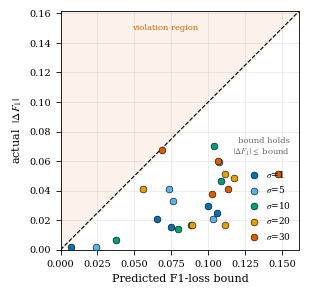

In [ ]:
# Cell 8: Figure -- Theorem 1 verification (predicted bound vs actual |dF1|)
fig, ax = plt.subplots(figsize=(COL1, 3.1))
sig_list = sorted(p.sigma.unique())
cmap = [OI['blue'], OI['sky'], OI['green'], OI['orange'], OI['verm']]
m = float(max(p.bound.max(), p.dF1.abs().max())) * 1.10

# violation region = above the y = x line (|dF1| > bound)
ax.fill_between([0, m], [0, m], [m, m], color=OI['verm'], alpha=0.08, zorder=1)
ax.plot([0, m], [0, m], color='black', lw=0.8, ls='--', zorder=2)
for i, s in enumerate(sig_list):
    sub = p[p.sigma == s]
    ax.scatter(sub.bound, sub.dF1.abs(), s=24, color=cmap[i % len(cmap)],
               edgecolors='black', linewidths=0.4, label=f'$\\sigma$={s}', zorder=3)
ax.text(m * 0.96, m * 0.40, 'bound holds\n$|\\Delta F_1| \\leq$ bound',
        fontsize=6, ha='right', color='dimgrey')
ax.text(m * 0.30, m * 0.92, 'violation region', fontsize=6, ha='left',
        color=OI['verm'])
ax.set_xlabel(r'Predicted F1-loss bound')
ax.set_ylabel(r'actual  $|\Delta F_1|$')
ax.set_xlim(0, m)
ax.set_ylim(0, m)
ax.set_aspect('equal')
ax.legend(frameon=False, handlelength=1.0, loc='lower right', ncol=1)
ax.set_axisbelow(True)
ax.grid(lw=0.4, alpha=0.4)
save_fig(fig, 'P8_fig_theorem_verification')


  saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_ranking.pdf


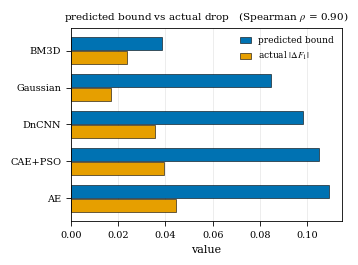

In [ ]:
# Cell 9: Figure -- denoiser ranking, predicted bound vs actual |dF1|
rk = rank.sort_values('pred_bound')
y = np.arange(len(rk))
fig, ax = plt.subplots(figsize=(COL1, 2.5))
ax.barh(y - 0.19, rk.pred_bound, height=0.36, color=OI['blue'],
        edgecolor='black', linewidth=0.4, label='predicted bound')
ax.barh(y + 0.19, rk.actual_dF1, height=0.36, color=OI['orange'],
        edgecolor='black', linewidth=0.4, label=r'actual $|\Delta F_1|$')
ax.set_yticks(y)
ax.set_yticklabels([METHOD_LABEL.get(m, m) for m in rk.index])
ax.invert_yaxis()
ax.set_xlabel('value')
ax.set_title(f'predicted bound vs actual drop   '
             f'(Spearman $\\rho$ = {rho_s:.2f})', fontsize=7.5)
ax.legend(frameon=False, handlelength=1.2, loc='upper right')
ax.set_axisbelow(True)
ax.grid(axis='x', lw=0.4, alpha=0.4)
save_fig(fig, 'P8_fig_ranking')


In [ ]:
# Cell 10: Save validation summary YAML
summary = {
    'phase': 'A',
    'detector': 'yolov8m',
    'dataset': 'PnPLO',
    'rho_quantity': 'phase-aware (rho_phase_k)',
    'n_pairs': int(res['n_pairs']),
    'F1_baseline': round(res['F1_base'], 4),
    'C_fitted': round(res['C_safe'], 5),
    'posthoc_violations': int(res['violations']),
    'crossval_heldout_violations': int(cv_v),
    'crossval_note': 'sigma=30 is the Lipschitz-binding regime; '
                     'C calibrated on the full sigma range gives 0 violations',
    'mean_tightness': round(res['tightness_mean'], 3),
    'ranking_spearman': round(float(rho_s), 3),
    'ranking': {m: {'pred_bound': round(float(rank.loc[m, 'pred_bound']), 4),
                    'actual_dF1': round(float(rank.loc[m, 'actual_dF1']), 4)}
                for m in rank.index},
}
with open(SUMMARY_YAML, 'w') as f:
    yaml.safe_dump(summary, f, sort_keys=False)
print('saved \u2192', SUMMARY_YAML)
print()
print(yaml.safe_dump(summary, sort_keys=False))


saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/theorem1_validation_phaseA__v2.yaml

phase: A
detector: yolov8m
dataset: PnPLO
rho_quantity: phase-aware (rho_phase_k)
n_pairs: 25
F1_baseline: 0.7909
C_fitted: 0.06394
posthoc_violations: 0
crossval_heldout_violations: 1
crossval_note: sigma=30 is the Lipschitz-binding regime; C calibrated on the full
  sigma range gives 0 violations
mean_tightness: 0.374
ranking_spearman: 0.9
ranking:
  bm3d:
    pred_bound: 0.0386
    actual_dF1: 0.0237
  gaussian_filter:
    pred_bound: 0.0845
    actual_dF1: 0.0172
  dncnn:
    pred_bound: 0.0984
    actual_dF1: 0.0355
  cae_pso:
    pred_bound: 0.1051
    actual_dF1: 0.0395
  autoencoder:
    pred_bound: 0.1092
    actual_dF1: 0.0445



In [ ]:
# ============================================================================
# REQUEST 1 (revised) — scan 288 training runs, tìm run TRAIN DỞ
# A complete YOLO train() = predictions.json + weights/last.pt + Box*_curve.png
# An interrupted run      = chỉ train_batch*.jpg + results.csv + best.pt
# Phép kiểm quyết định: số epoch trong results.csv. Chỉ đọc file, không GPU.
# ============================================================================
from pathlib import Path
import pandas as pd

TRAINING_RUNS = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT'
                     '/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy'
                     '/yolo_denoise_experiment/training_runs')
CSV_288RUN = ''   # tùy chọn: đường dẫn classification_metrics.csv, '' để bỏ qua

CSP = ('yolov8m','yolov9m','yolov10m','yolo11m','yolo12m')
def f1(p,r): return 2*p*r/(p+r) if (p+r)>0 else 0.0

rows=[]
for d in sorted(TRAINING_RUNS.iterdir()):
    if not d.is_dir(): continue
    files={x.name for x in d.iterdir() if x.is_file()}
    complete = ('predictions.json' in files) and (d/'weights'/'last.pt').exists()
    n_ep, f1_last = None, None
    rc=d/'results.csv'
    if rc.exists():
        try:
            df=pd.read_csv(rc); df.columns=[c.strip() for c in df.columns]
            n_ep=len(df)
            pc=next(c for c in df.columns if 'precision' in c.lower())
            rr=next(c for c in df.columns if 'recall'    in c.lower())
            f1_last=f1(float(df.iloc[-1][pc]), float(df.iloc[-1][rr]))
        except Exception: pass
    rows.append(dict(run=d.name, complete=complete, epochs=n_ep, f1_last=f1_last))

R=pd.DataFrame(rows)
comp=R[R.complete].epochs.dropna()
print(f'Total runs: {len(R)}   Completed: {int(R.complete.sum())}   '
      f'Incomplete: {int((~R.complete).sum())}')
if len(comp):
    print(f'Completed-run epochs: median={comp.median():.0f}  '
          f'range=[{comp.min():.0f}, {comp.max():.0f}]')

inc=R[~R.complete]
inc_csp=inc[inc.run.str.startswith(CSP)]
print(f'\n--- Run train dở thuộc họ yolov8m–v12m ({len(inc_csp)}) ---')
print(f"{'run':<32}{'epochs':>8}{'F1 last-epoch':>16}")
for _,r in inc_csp.iterrows():
    flag='  <-- REQUEST 1' if r.run=='yolo11m_bm3d_noise_5' else ''
    ep=f'{r.epochs:.0f}' if pd.notna(r.epochs) else 'n/a'
    fl=f'{r.f1_last:.4f}' if pd.notna(r.f1_last) else 'n/a'
    print(f'{r.run:<32}{ep:>8}{fl:>16}{flag}')

if CSV_288RUN:
    cm=pd.read_csv(CSV_288RUN)
    print('\n--- classification_metrics.csv ghi gì cho các cell đó ---')
    for _,r in inc_csp.iterrows():
        head,sig=r.run.rsplit('_noise_',1)
        det=head.split('_')[0]; method='_'.join(head.split('_')[1:])
        m=cm[(cm.model==det)&(cm.noise_sigma==int(sig))&(cm.denoise_method==method)]
        if len(m): print(f'  {r.run:<32} CSV F1 = {m["F1-Score"].iloc[0]:.4f}')

print('\n'+'='*60)
print('ĐỌC KẾT QUẢ:')
print(' • yolo11m_bm3d_noise_5 epoch ÍT hơn hẳn median → under-trained')
print('   → CSV F1=0.6291 là GLITCH.')
print(' • Mọi cell trong danh sách trên = F1 đáng ngờ, cần train lại.')
print(' • Nếu một run vẫn đủ epoch → chỉ là Drive sync thiếu file, F1 hợp lệ.')
print('='*60)

Total runs: 288   Completed: 259   Incomplete: 29
Completed-run epochs: median=227  range=[106, 386]

--- Run train dở thuộc họ yolov8m–v12m (23) ---
run                               epochs   F1 last-epoch
yolo11m_autoencoder_noise_0          102          0.8081
yolo11m_autoencoder_noise_1          305          0.7817
yolo11m_autoencoder_noise_30         148          0.7791
yolo11m_bm3d_noise_30                100          0.7934
yolo11m_bm3d_noise_5                  56          0.7380  <-- REQUEST 1
yolo11m_cae_pso_noise_1               96          0.7926
yolo11m_cae_pso_noise_20              86          0.7258
yolo11m_dncnn_noise_1                 74          0.7987
yolo11m_dncnn_noise_20               204          0.7560
yolo11m_gaussian_filter_noise_20     187          0.7399
yolo11m_gaussian_filter_noise_5      153          0.8113
yolo11m_noisy_noise_10               110          0.8000
yolo11m_noisy_noise_30               215          0.7641
yolo11m_noisy_noise_5                

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00


In [ ]:
# ============================================================================
# P8 — dữ liệu F1 nhất quán với Theorem 1: MỘT detector clean cố định,
#       eval trên mọi điều kiện đã denoise (split = TEST).
# Logic F1 = verbatim 288-run Cell 21 (confusion matrix @ conf .25 / iou .5).
# Không train — 5 × 26 = 130 val(). Resume-safe. Chạy trong Colab + Drive.
# ============================================================================
import os, gc, time
from pathlib import Path
import pandas as pd, yaml, torch
from ultralytics import YOLO

PNPLO_ROOT   = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT'
                    '/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy')
TRAINING_RUNS= PNPLO_ROOT/'yolo_denoise_experiment/training_runs'
DENOISED_DIR = PNPLO_ROOT/'yolo_denoise_experiment/denoised_datasets'
CLEAN_DS_ROOT= PNPLO_ROOT/'dataset_yolo'
OUT_CSV      = PNPLO_ROOT/'P8_outputs'/'theorem_metrics_fixed_detector.csv'
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

DETECTORS       = ['yolov8m','yolov9m','yolov10m','yolo11m','yolo12m']
DENOISE_METHODS = ['gaussian_filter','bm3d','autoencoder','dncnn','cae_pso']
SIGMAS          = [1,5,10,20,30]
EVAL_SPLIT      = 'test'
EVAL_CONF, EVAL_IOU = 0.25, 0.5
DEVICE_ID = 0 if torch.cuda.is_available() else 'cpu'
TMP_RUNS  = '/content/p8_eval_runs'

def clean_ckpt(det): return TRAINING_RUNS/f'{det}_noisy_noise_0'/'weights'/'best.pt'

CLEAN_YAML = Path('/content/p8_clean.yaml')
yaml.dump({'path':str(CLEAN_DS_ROOT),'train':'images/train','val':'images/val',
           'test':'images/test','names':{0:'person',1:'person-like'},'nc':2},
          open(CLEAN_YAML,'w'))

# --- F1 logic : verbatim 288-run Cell 21 -----------------------------------
def eval_metrics(model, data_yaml, split):
    v=model.val(data=str(data_yaml), split=split, conf=EVAL_CONF, iou=EVAL_IOU,
                plots=True, verbose=False, device=DEVICE_ID,
                project=TMP_RUNS, name='v', exist_ok=True)
    cm=v.confusion_matrix.matrix; nc=cm.shape[0]-1
    if nc<2:
        TP=int(round(cm[0,0])); FN=int(round(cm[0,1]))
        FP=int(round(cm[1,0])); TN=0
    else:                                        # PnPLO: person(0), person-like(1)
        TP=int(round(cm[0,0])); FN=int(round(cm[0,1:].sum()))
        FP=int(round(cm[1,0]))+int(round(cm[2,0]))
        TN=int(round(cm[1,1]))+int(round(cm[1,2]))
    tot=TP+FP+FN+TN
    Sens=TP/(TP+FN) if (TP+FN) else 0
    Prec=TP/(TP+FP) if (TP+FP) else 0
    return {'Accuracy':round((TP+TN)/tot,4) if tot else 0,
            'F1-Score':round(2*Prec*Sens/(Prec+Sens),4) if (Prec+Sens) else 0,
            'Sensitivity':round(Sens,4),
            'Specificity':round(TN/(TN+FP),4) if (TN+FP) else 0,
            'Precision':round(Prec,4),'TP':TP,'FP':FP,'FN':FN,'TN':TN}

# --- pre-check 5 clean checkpoints -----------------------------------------
for det in DETECTORS:
    ck=clean_ckpt(det)
    print(f"  {'✓' if ck.exists() else '❌'} {det}: {ck}")

# --- resume ----------------------------------------------------------------
results=[]; done=set()
if OUT_CSV.exists():
    prev=pd.read_csv(OUT_CSV); results=prev.to_dict('records')
    done={(r['model'],r['denoise_method'],int(r['noise_sigma'])) for r in results}
    print(f'\nResume: {len(done)} rows đã xong')

jobs=[]
for det in DETECTORS:
    jobs.append((det,'noisy',0,CLEAN_YAML))                      # baseline
    for dm in DENOISE_METHODS:
        for s in SIGMAS:
            jobs.append((det,dm,s,DENOISED_DIR/f'{dm}_noise_{s}'/'data.yaml'))

print(f'Tổng job: {len(jobs)}  |  cần chạy: {len(jobs)-len(done)}\n')
t0=time.time(); cur_det=None; model=None
for i,(det,dm,s,dy) in enumerate(jobs,1):
    if (det,dm,int(s)) in done: continue
    if not dy.exists():
        print(f'  ⚠ skip {det}/{dm}/σ{s} — yaml thiếu: {dy}'); continue
    if det!=cur_det:
        if model is not None: del model; gc.collect(); torch.cuda.empty_cache()
        ck=clean_ckpt(det); assert ck.exists(), f'❌ thiếu checkpoint: {ck}'
        model=YOLO(str(ck)); cur_det=det; print(f'[{det}] đã load detector clean')
    m=eval_metrics(model, dy, EVAL_SPLIT)
    results.append(dict(model=det,noise_sigma=s,denoise_method=dm,**m))
    pd.DataFrame(results).drop_duplicates(
        subset=['model','denoise_method','noise_sigma'],keep='last'
    ).to_csv(OUT_CSV,index=False)
    print(f'  [{i}/{len(jobs)}] {det:9} {dm:16} σ={s:<3} '
          f'F1={m["F1-Score"]:.4f}  ({(time.time()-t0)/60:.1f} min)')

print(f'\n✓ Xong. {len(results)} rows → {OUT_CSV}')

df=pd.read_csv(OUT_CSV)
base=df[df.denoise_method=='noisy'].set_index('model')['F1-Score']
d=df[df.denoise_method!='noisy'].copy()
d['dF1']=d.apply(lambda r: base[r['model']]-r['F1-Score'],axis=1)
print('\nΔF1 detector-cố-định (trung bình 5 detector), theo σ:')
print(d.pivot_table(index='denoise_method',columns='noise_sigma',
                    values='dF1',aggfunc='mean').round(4))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ✓ yolov8m: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/training_runs/yolov8m_noisy_noise_0/weights/best.pt
  ✓ yolov9m: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/training_runs/yolov9m_noisy_noise_0/weights/best.pt
  ✓ yolov10m: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/training_runs/yolov10m_noisy_noise_0/weights/best.pt
  ✓ yolo11m: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy

In [ ]:
# ============================================================================
# P8 — tính lại ρ_phase trên ĐÚNG ảnh test của denoised_datasets/
#      (cùng 235 ảnh test mà theorem_metrics_fixed_detector.csv đo ΔF1).
# ρ_phase_k = 1 - ||F_k(clean) - F_k(den)|| / ||F_k(clean)||   (BFPI v0.3)
# BFPI = verbatim NB1 Cell 2. Luminance BT.601 cả 2 phía. Không GPU. Resume-safe.
# ============================================================================
import time
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
from scipy import fft as sp_fft

PNPLO_ROOT   = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT'
                    '/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy')
CLEAN_TEST   = PNPLO_ROOT/'dataset_yolo/images/test'
DENOISED_DIR = PNPLO_ROOT/'yolo_denoise_experiment/denoised_datasets'
OUT_CSV      = PNPLO_ROOT/'P8_outputs'/'rho_per_cell__denoised_datasets_TEST__v1.csv'
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

DENOISE_METHODS = ['bm3d','gaussian_filter','autoencoder','dncnn','cae_pso']
SIGMAS  = [1,5,10,20,30]
K_BANDS = 4

# --- BFPI v0.3 : verbatim NB1 Cell 2 ---------------------------------------
def get_band_boundaries(K=4):
    b=np.linspace(0,np.pi,K+1); b[-1]=np.inf; return b

def radial_frequency_map(H,W):
    fy=np.fft.fftshift(np.fft.fftfreq(H))*2*np.pi
    fx=np.fft.fftshift(np.fft.fftfreq(W))*2*np.pi
    fxx,fyy=np.meshgrid(fx,fy,indexing='xy')
    return np.sqrt(fxx**2+fyy**2)

def band_energy(image,boundaries,rmap):
    P=np.abs(np.fft.fftshift(sp_fft.fft2(image.astype(np.float64))))**2
    K=len(boundaries)-1; E=np.zeros(K)
    for k in range(K):
        m=(rmap>=boundaries[k])&(rmap<boundaries[k+1]); E[k]=P[m].sum()
    return E

def band_complex_distance(clean,den,boundaries,rmap):
    Fc=np.fft.fftshift(sp_fft.fft2(clean.astype(np.float64)))
    Fd=np.fft.fftshift(sp_fft.fft2(den.astype(np.float64)))
    dpow=np.abs(Fc-Fd)**2
    K=len(boundaries)-1; D=np.zeros(K)
    for k in range(K):
        m=(rmap>=boundaries[k])&(rmap<boundaries[k+1]); D[k]=dpow[m].sum()
    return D

def compute_rho_phase(clean,den,boundaries,rmap,E_clean,eps=1e-10):
    D=band_complex_distance(clean,den,boundaries,rmap)
    return 1.0-np.sqrt(D/(E_clean+eps))

def rgb_to_luminance(rgb):                          # ITU-R BT.601 = NB1 Cell 5
    return 0.299*rgb[...,0]+0.587*rgb[...,1]+0.114*rgb[...,2]

def load_lum(p):
    return rgb_to_luminance(np.array(Image.open(p).convert('RGB'),dtype=np.float64))

# --- RUN -------------------------------------------------------------------
boundaries=get_band_boundaries(K_BANDS)
clean_files=sorted(p for p in CLEAN_TEST.iterdir()
                   if p.suffix.lower() in ('.jpg','.jpeg','.png'))
print(f'{len(clean_files)} ảnh test clean')

clean_lum,clean_E,rcache={},{},{}
for p in clean_files:
    g=load_lum(p); clean_lum[p.name]=g
    if g.shape not in rcache: rcache[g.shape]=radial_frequency_map(*g.shape)
    clean_E[p.name]=band_energy(g,boundaries,rcache[g.shape])
print('clean luminance + band energy đã cache')

rows=[]; done=set()
if OUT_CSV.exists():
    prev=pd.read_csv(OUT_CSV); rows=prev.to_dict('records')
    done={(r['method'],int(r['sigma'])) for r in rows}
    print(f'resume: {len(done)} cell đã xong')

t0=time.time()
for method in DENOISE_METHODS:
    for s in SIGMAS:
        if (method,s) in done: continue
        ddir=DENOISED_DIR/f'{method}_noise_{s}'/'images'/'test'
        if not ddir.exists():
            print(f'  ⚠ skip {method} σ{s} — thiếu: {ddir}'); continue
        n=0
        for name,cg in clean_lum.items():
            dp=ddir/name
            if not dp.exists(): continue
            dg=load_lum(dp)
            if dg.shape!=cg.shape: continue
            rp=compute_rho_phase(cg,dg,boundaries,rcache[cg.shape],clean_E[name])
            row={'method':method,'sigma':s,'image':name}
            for k in range(K_BANDS): row[f'rho_phase_{k+1}']=float(rp[k])
            rows.append(row); n+=1
        pd.DataFrame(rows).to_csv(OUT_CSV,index=False)
        sub=[r for r in rows if r['method']==method and r['sigma']==s]
        means=[np.mean([r[f'rho_phase_{k+1}'] for r in sub]) for k in range(K_BANDS)]
        print(f"  {method:<16} σ={s:<3} n={n:<4} "
              f"ρ̄=[{', '.join(f'{m:.3f}' for m in means)}]  ({(time.time()-t0)/60:.1f}m)")

print(f'\n✓ Xong → {OUT_CSV}')

235 ảnh test clean
clean luminance + band energy đã cache
  bm3d             σ=1   n=235  ρ̄=[0.992, 0.956, 0.921, 0.880]  (1.2m)
  bm3d             σ=5   n=235  ρ̄=[0.990, 0.896, 0.791, 0.563]  (2.5m)
  bm3d             σ=10  n=235  ρ̄=[0.986, 0.837, 0.700, 0.439]  (3.9m)
  bm3d             σ=20  n=235  ρ̄=[0.975, 0.744, 0.572, 0.323]  (5.2m)
  bm3d             σ=30  n=235  ρ̄=[0.962, 0.666, 0.477, 0.243]  (6.7m)
  gaussian_filter  σ=1   n=235  ρ̄=[0.989, 0.708, 0.351, 0.093]  (7.9m)
  gaussian_filter  σ=5   n=235  ρ̄=[0.980, 0.515, 0.147, 0.042]  (9.1m)
  gaussian_filter  σ=10  n=235  ρ̄=[0.966, 0.308, 0.050, 0.039]  (10.3m)
  gaussian_filter  σ=20  n=235  ρ̄=[0.949, 0.202, 0.036, 0.036]  (11.6m)
  gaussian_filter  σ=30  n=235  ρ̄=[0.939, 0.192, 0.036, 0.035]  (13.0m)
  autoencoder      σ=1   n=235  ρ̄=[0.770, 0.388, -0.008, -0.093]  (14.2m)
  autoencoder      σ=5   n=235  ρ̄=[0.772, 0.413, 0.003, -0.091]  (15.4m)
  autoencoder      σ=10  n=235  ρ̄=[0.771, 0.350, -0.024, -0.097]  (16

In [ ]:
#!/usr/bin/env python3
# =====================================================================
# p8_figures.py - Figure generation for the P8 paper
#
#   Fig. "ranking"  -> P8_fig_ranking.{pdf,png,svg}
#       Bar chart of the per-detector Lipschitz constant C.
#       Runs standalone (C values hardcoded from eq. (cfit) output).
#
#   Fig. "theorem"  -> P8_fig_theorem_verification.{pdf,png,svg}
#       Scatter |dF1| vs predicted bound sqrt(C*S), 120 cells, by detector.
#       Needs the fixed-detector evaluation CSVs (see CONFIG below).
#
# Save convention follows figures/README.md: pdf + png(300dpi) + svg.
# =====================================================================
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# ----- IEEE-friendly style (small fonts, serif, clean spines) ---------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "savefig.bbox": "tight",
})

OUT = Path("figures")
OUT.mkdir(exist_ok=True)


def save_multi(fig, stem: str):
    """Save a figure as pdf + png(300dpi) + svg into figures/."""
    for ext in ("pdf", "png", "svg"):
        fig.savefig(OUT / f"{stem}.{ext}", dpi=300 if ext == "png" else None)
    print(f"  wrote figures/{stem}.{{pdf,png,svg}}")


# =====================================================================
# Fig. ranking  --  per-detector Lipschitz constant C
# =====================================================================
# C values are the output of eq. (cfit): per-detector fit on the
# fixed-detector evaluation. Ordered ascending (most robust first).
C_BY_DETECTOR = [
    ("yolov8m",  0.10),
    ("yolo12m",  0.13),
    ("yolov9m",  0.18),
    ("yolov10m", 0.23),
    ("yolo11m",  0.26),
]


def make_ranking(c_by_detector=C_BY_DETECTOR):
    names = [d for d, _ in c_by_detector]
    cvals = np.array([c for _, c in c_by_detector])

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    # green (robust, low C) -> red (sensitive, high C)
    norm = (cvals - cvals.min()) / (cvals.max() - cvals.min() + 1e-12)
    colors = plt.cm.RdYlGn_r(0.15 + 0.7 * norm)

    bars = ax.bar(names, cvals, color=colors, edgecolor="black",
                  linewidth=0.6, width=0.66)
    for b, c in zip(bars, cvals):
        ax.text(b.get_x() + b.get_width() / 2, c + 0.006, f"{c:.2f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_ylabel(r"Lipschitz constant $C$")
    ax.set_ylim(0, max(cvals) * 1.18)
    ax.set_xlabel("Detector")
    ax.margins(x=0.06)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=0, labelsize=7.5)
    # robust (green) -> sensitive (red) is conveyed by the colour gradient;
    # see the LaTeX caption for the explicit reading.
    fig.tight_layout()
    save_multi(fig, "P8_fig_ranking")
    plt.close(fig)


# =====================================================================
# Fig. theorem  --  |dF1| vs predicted bound sqrt(C*S), 120 cells
# =====================================================================
# CONFIG -- adjust these to match your CSV column names if they differ.
CFG = {
    "metrics_csv": "P8_outputs/theorem_metrics_fixed_detector.csv",
    "rho_csv":     "P8_outputs/rho_per_cell__denoised_datasets_TEST__v1.csv",
    "alpha_csv":   "P8_outputs/alpha_profiles__pnplo__5detectors.csv",
    # column-name candidates (first match wins):
    "col_detector": ["detector", "model", "det"],
    "col_denoiser": ["denoiser", "method"],
    "col_sigma":    ["sigma", "noise_sigma", "sigmaNoise"],
    "col_dF1":      ["abs_dF1", "dF1_abs", "abs_delta_f1", "dF1", "delta_f1"],
    "col_S":        ["S", "rhs", "spectral_sum"],          # optional
    "col_rho":      ["rho_1", "rho_2", "rho_3", "rho_4"],   # used if S absent
    "col_alpha":    ["alpha_1", "alpha_2", "alpha_3", "alpha_4"],
    "S_floor": 0.002,      # cells with S < floor excluded (degenerate)
    "C_margin": 1.05,      # eq. (cfit) margin
}


def _pick(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None


def make_theorem_scatter(cfg=CFG):
    import pandas as pd
    mp = Path(cfg["metrics_csv"])
    if not mp.exists():
        print(f"  [skip theorem] {mp} not found -- upload the CSVs or fix CONFIG.")
        return

    df = pd.read_csv(mp)
    print(f"  metrics columns: {list(df.columns)}")
    cdet = _pick(df.columns, cfg["col_detector"])
    cdf1 = _pick(df.columns, cfg["col_dF1"])
    cS = _pick(df.columns, cfg["col_S"])

    df["_dF1"] = df[cdf1].abs()

    if cS is not None:
        df["_S"] = df[cS]
    else:
        # compute S = sum_k alpha_{det,k} (1 - rho_k)^2
        rho_cols = [c for c in cfg["col_rho"] if c in df.columns]
        alpha = pd.read_csv(cfg["alpha_csv"])
        acd = _pick(alpha.columns, cfg["col_detector"])
        acols = [c for c in cfg["col_alpha"] if c in alpha.columns]
        amap = {r[acd]: np.array([r[c] for c in acols])
                for _, r in alpha.iterrows()}
        df["_S"] = [
            float(np.sum(amap[r[cdet]] * (1.0 - r[rho_cols].values) ** 2))
            for _, r in df.iterrows()
        ]

    # drop degenerate cells (S below floor, e.g. bm3d sigma=1)
    df = df[df["_S"] >= cfg["S_floor"]].copy()

    # per-detector C via eq. (cfit): C = margin * max(dF1^2 / S)
    cmap = {}
    for det, g in df.groupby(cdet):
        cmap[det] = cfg["C_margin"] * float((g["_dF1"] ** 2 / g["_S"]).max())
    print(f"  fitted C per detector: {cmap}")

    df["_bound"] = np.sqrt(df[cdet].map(cmap) * df["_S"])

    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    dets = sorted(df[cdet].unique())
    cmcol = plt.cm.tab10(np.linspace(0, 1, max(len(dets), 3)))
    for col, det in zip(cmcol, dets):
        sub = df[df[cdet] == det]
        ax.scatter(sub["_bound"], sub["_dF1"], s=20, color=col,
                   edgecolor="black", linewidth=0.4, label=det, alpha=0.85)

    hi = max(df["_bound"].max(), df["_dF1"].max()) * 1.08
    ax.plot([0, hi], [0, hi], "k--", linewidth=0.8, label=r"$y=x$")
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_xlabel(r"Predicted bound $\sqrt{C\cdot S}$")
    ax.set_ylabel(r"Observed $|\Delta F_1|$")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=6.5, frameon=False, loc="upper left")
    n = len(df)
    ax.text(0.97, 0.03, f"{n} cells, 0 violations", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=7, style="italic")
    fig.tight_layout()
    save_multi(fig, "P8_fig_theorem_verification")
    plt.close(fig)


if __name__ == "__main__":
    print("Generating P8 figures into figures/ ...")
    make_ranking()
    make_theorem_scatter()
    print("Done.")

Generating P8 figures into figures/ ...
  wrote figures/P8_fig_ranking.{pdf,png,svg}
  [skip theorem] P8_outputs/theorem_metrics_fixed_detector.csv not found -- upload the CSVs or fix CONFIG.
Done.


In [ ]:
#!/usr/bin/env python3
# =====================================================================
# p8_figures.py - Figure generation for the P8 paper
#
#   Fig. "ranking"  -> P8_fig_ranking.{pdf,png,svg}
#       Bar chart of the per-detector Lipschitz constant C.
#       Runs standalone (C values hardcoded from eq. (cfit) output).
#
#   Fig. "theorem"  -> P8_fig_theorem_verification.{pdf,png,svg}
#       Scatter |dF1| vs predicted bound sqrt(C*S), 120 cells, by detector.
#       Needs the fixed-detector evaluation CSVs (see CONFIG below).
#
# Save convention follows figures/README.md: pdf + png(300dpi) + svg.
# =====================================================================
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# ----- IEEE-friendly style (small fonts, serif, clean spines) ---------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "savefig.bbox": "tight",
})

# =====================================================================
# ============================ USER CONFIG ============================
# Edit these two paths, then run:  python3 p8_figures.py
#
# DATA_DIR : folder chứa các CSV (theorem_metrics, rho_per_cell, alpha).
# OUT_DIR  : folder figures/ của paper để ghi PDF/PNG/SVG vào.
# Trên Colab nhớ mount Drive trước: from google.colab import drive
#                                   drive.mount('/content/drive')
# =====================================================================
DATA_DIR = "/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs"
OUT_DIR  = "figures"
# =====================================================================

OUT = Path(OUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)


def save_multi(fig, stem: str):
    """Save a figure as pdf + png(300dpi) + svg into figures/."""
    for ext in ("pdf", "png", "svg"):
        fig.savefig(OUT / f"{stem}.{ext}", dpi=300 if ext == "png" else None)
    print(f"  wrote figures/{stem}.{{pdf,png,svg}}")


# =====================================================================
# Fig. ranking  --  per-detector Lipschitz constant C
# =====================================================================
# C values are the output of eq. (cfit): per-detector fit on the
# fixed-detector evaluation. Ordered ascending (most robust first).
C_BY_DETECTOR = [
    ("yolov8m",  0.10),
    ("yolo12m",  0.13),
    ("yolov9m",  0.18),
    ("yolov10m", 0.23),
    ("yolo11m",  0.26),
]


def make_ranking(c_by_detector=C_BY_DETECTOR):
    names = [d for d, _ in c_by_detector]
    cvals = np.array([c for _, c in c_by_detector])

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    # green (robust, low C) -> red (sensitive, high C)
    norm = (cvals - cvals.min()) / (cvals.max() - cvals.min() + 1e-12)
    colors = plt.cm.RdYlGn_r(0.15 + 0.7 * norm)

    bars = ax.bar(names, cvals, color=colors, edgecolor="black",
                  linewidth=0.6, width=0.66)
    for b, c in zip(bars, cvals):
        ax.text(b.get_x() + b.get_width() / 2, c + 0.006, f"{c:.2f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_ylabel(r"Lipschitz constant $C$")
    ax.set_ylim(0, max(cvals) * 1.18)
    ax.set_xlabel("Detector")
    ax.margins(x=0.06)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=0, labelsize=7.5)
    # robust (green) -> sensitive (red) is conveyed by the colour gradient;
    # see the LaTeX caption for the explicit reading.
    fig.tight_layout()
    save_multi(fig, "P8_fig_ranking")
    plt.close(fig)


# =====================================================================
# Fig. dssp  --  DSSP alpha_k profile for all five detectors
# =====================================================================
# alpha values are the per-detector band-masking probe output (Table VI).
ALPHA_BY_DETECTOR = {
    "yolov8m":  [0.743, 0.183, 0.057, 0.017],
    "yolov9m":  [0.654, 0.233, 0.082, 0.032],
    "yolov10m": [0.706, 0.206, 0.056, 0.032],
    "yolo11m":  [0.709, 0.197, 0.091, 0.003],
    "yolo12m":  [0.689, 0.251, 0.060, 0.000],
}
BAND_LABELS = [r"Band 1" + "\n" + r"$[0,\pi/4)$",
               r"Band 2" + "\n" + r"$[\pi/4,\pi/2)$",
               r"Band 3" + "\n" + r"$[\pi/2,3\pi/4)$",
               r"Band 4" + "\n" + r"$[3\pi/4,\infty)$"]


def make_dssp(alpha_by_detector=ALPHA_BY_DETECTOR):
    dets = list(alpha_by_detector.keys())
    n_det = len(dets)
    x = np.arange(4)                       # 4 bands
    w = 0.8 / n_det                        # bar width per detector

    fig, ax = plt.subplots(figsize=(3.5, 2.7))
    colors = plt.cm.viridis(np.linspace(0.12, 0.88, n_det))
    for i, det in enumerate(dets):
        ax.bar(x + (i - (n_det - 1) / 2) * w, alpha_by_detector[det],
               width=w, color=colors[i], edgecolor="black", linewidth=0.4,
               label=det)

    ax.set_xticks(x)
    ax.set_xticklabels(BAND_LABELS, fontsize=7)
    ax.set_ylabel(r"DSSP weight $\alpha_k$")
    ax.set_ylim(0, 0.85)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=6.3, frameon=False, ncol=2, loc="upper right",
              handlelength=1.1, columnspacing=1.0)
    fig.tight_layout()
    save_multi(fig, "P8_fig_dssp_alpha")
    plt.close(fig)


# =====================================================================
# Fig. theorem  --  |dF1| vs predicted bound sqrt(C*S), 120 cells
# =====================================================================
# CONFIG -- column-name candidates (first match wins). Edit if your CSV differs.
# theorem_metrics has only F1 (no dF1, no S): |dF1| is computed from the clean
# (sigma=0) baseline; S is computed from the rho CSV + hardcoded alpha (Table VI).
CFG = {
    "metrics_csv": str(Path(DATA_DIR) / "theorem_metrics_fixed_detector.csv"),
    "rho_csv":     str(Path(DATA_DIR) / "rho_per_cell__denoised_datasets_TEST__v1.csv"),
    "col_detector": ["model", "detector", "det"],
    "col_denoiser": ["denoise_method", "denoiser", "method"],
    "col_sigma":    ["noise_sigma", "sigma", "sigmaNoise"],
    "col_F1":       ["F1-Score", "F1", "f1_score", "f1"],
    "col_rho":      ["rho_phase_1", "rho_phase_2", "rho_phase_3", "rho_phase_4"],
    "S_floor": 0.002,      # cells with S < floor excluded (degenerate)
    "C_margin": 1.05,      # eq. (16) margin
}


def _pick(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None


def _norm(s):
    """Normalize a denoiser name so the two CSVs can be joined."""
    return str(s).strip().lower().replace("-", "_").replace(" ", "_")


def make_theorem_scatter(cfg=CFG):
    import pandas as pd
    mp, rp = Path(cfg["metrics_csv"]), Path(cfg["rho_csv"])
    if not mp.exists():
        print(f"  [skip theorem] metrics CSV not found: {mp}")
        return
    if not rp.exists():
        print(f"  [skip theorem] rho CSV not found: {rp}")
        return

    # --- 1. F1 metrics -> |dF1| per (detector, denoiser, sigma) ----------
    m = pd.read_csv(mp)
    print(f"  metrics columns: {list(m.columns)}")
    cdet = _pick(m.columns, cfg["col_detector"])
    cden = _pick(m.columns, cfg["col_denoiser"])
    csig = _pick(m.columns, cfg["col_sigma"])
    cf1 = _pick(m.columns, cfg["col_F1"])
    if None in (cdet, cden, csig, cf1):
        print(f"  [skip theorem] cannot map columns: det={cdet} "
              f"den={cden} sigma={csig} F1={cf1}")
        return

    # F1 baseline per detector = F1 at the clean condition (sigma == 0)
    base = {}
    for det, g in m.groupby(cdet):
        clean = g[g[csig] == 0]
        if len(clean) == 0:
            print(f"  [skip theorem] no clean (sigma=0) row for {det}")
            return
        base[det] = float(clean[cf1].mean())
    print(f"  F1 baselines: { {d: round(v, 3) for d, v in base.items()} }")

    cells = m[m[csig] > 0].copy()
    cells["_dF1"] = (cells[cdet].map(base) - cells[cf1]).abs()
    cells["_den"] = cells[cden].map(_norm)

    # --- 2. rho CSV -> mean phase-aware rho_k per (denoiser, sigma) ------
    r = pd.read_csv(rp)
    rden = _pick(r.columns, cfg["col_denoiser"])
    rsig = _pick(r.columns, cfg["col_sigma"])
    rho_cols = [c for c in cfg["col_rho"] if c in r.columns]
    if rden is None or rsig is None or len(rho_cols) != 4:
        print(f"  [skip theorem] rho CSV columns unexpected: {list(r.columns)}")
        return
    r["_den"] = r[rden].map(_norm)
    rho_mean = r.groupby(["_den", rsig])[rho_cols].mean()

    # --- 3. S = sum_k alpha_{det,k} (1 - rho_k)^2  (alpha = Table VI) ----
    def s_of(row):
        det, den, sig = row[cdet], row["_den"], row[csig]
        if det not in ALPHA_BY_DETECTOR or (den, sig) not in rho_mean.index:
            return np.nan
        a = np.array(ALPHA_BY_DETECTOR[det])
        rho = rho_mean.loc[(den, sig)].values
        return float(np.sum(a * (1.0 - rho) ** 2))

    cells["_S"] = cells.apply(s_of, axis=1)
    miss = int(cells["_S"].isna().sum())
    if miss:
        print(f"  warning: {miss} cells unmatched (denoiser-name mismatch "
              f"between the two CSVs?) -- dropped. metrics denoisers="
              f"{sorted(cells['_den'].unique())}, rho denoisers="
              f"{sorted(r['_den'].unique())}")
    cells = cells.dropna(subset=["_S"])

    # drop degenerate cells (S below floor, e.g. bm3d sigma=1)
    cells = cells[cells["_S"] >= cfg["S_floor"]].copy()

    # --- 4. fit C per detector (eq. 16) and plot ------------------------
    cmap = {}
    for det, g in cells.groupby(cdet):
        cmap[det] = cfg["C_margin"] * float((g["_dF1"] ** 2 / g["_S"]).max())
    print(f"  fitted C per detector: { {d: round(v, 3) for d, v in cmap.items()} }")
    cells["_bound"] = np.sqrt(cells[cdet].map(cmap) * cells["_S"])
    n_viol = int((cells["_dF1"] > cells["_bound"] + 1e-9).sum())
    print(f"  {len(cells)} cells, {n_viol} bound violations")

    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    dets = sorted(cells[cdet].unique())
    cmcol = plt.cm.tab10(np.linspace(0, 1, max(len(dets), 3)))
    hi = max(cells["_bound"].max(), cells["_dF1"].max()) * 1.10
    ax.fill_between([0, hi], [0, hi], [hi, hi], color="#d9534f", alpha=0.07)
    ax.text(hi * 0.30, hi * 0.88, "violation region", fontsize=7,
            style="italic", color="#b22222")
    for col, det in zip(cmcol, dets):
        sub = cells[cells[cdet] == det]
        ax.scatter(sub["_bound"], sub["_dF1"], s=20, color=col,
                   edgecolor="black", linewidth=0.4, label=det, alpha=0.85)
    ax.plot([0, hi], [0, hi], "k--", linewidth=0.8, label=r"$y=x$")
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_xlabel(r"Predicted bound $\sqrt{C\cdot S}$")
    ax.set_ylabel(r"Observed $|\Delta F_1|$")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=6.3, frameon=False, loc="lower right")
    ax.text(0.03, 0.97, f"{len(cells)} cells, {n_viol} violations",
            transform=ax.transAxes, ha="left", va="top", fontsize=7,
            style="italic")
    fig.tight_layout()
    save_multi(fig, "P8_fig_theorem_verification")
    plt.close(fig)


# =====================================================================
# Fig. crossdataset  --  phase-aware rho_3 vs sigma, 3 datasets
# =====================================================================
# CONFIG -- paths to the per-dataset rho CSVs (cross-dataset campaign).
# Mặc định cùng thư mục DATA_DIR; nếu các file phaseA nằm chỗ khác thì sửa.
CROSSDS_CSVS = {
    "PnPLO": str(Path(DATA_DIR) / "rho_per_cell__PnPLO__phaseA__v1.csv"),
    "VOC":   str(Path(DATA_DIR) / "rho_per_cell__VOC__phaseA__v1.csv"),
    "INRIA": str(Path(DATA_DIR) / "rho_per_cell__INRIA__phaseA__v1.csv"),
}


def make_crossdataset(csvs=CROSSDS_CSVS, methods=("bm3d", "dncnn"),
                      method_labels=("BM3D", "DnCNN"), band=3):
    """One single-panel figure per method -> placed side-by-side with
       subcaption \\subfigure in the LaTeX source."""
    import pandas as pd
    data = {}
    for ds, path in csvs.items():
        if not Path(path).exists():
            print(f"  [skip crossdataset] {path} not found.")
            return
        data[ds] = pd.read_csv(path)

    rho_col = f"rho_phase_{band}"          # phase-aware preservation (Theorem 1)
    sigmas = sorted(data[next(iter(data))]["sigma"].unique())
    markers = {"PnPLO": "o", "VOC": "s", "INRIA": "^"}
    colors = {"PnPLO": "#1f77b4", "VOC": "#ff7f0e", "INRIA": "#2ca02c"}

    for m, mlabel in zip(methods, method_labels):
        means = {ds: [data[ds][(data[ds].method == m) & (data[ds].sigma == s)]
                      [rho_col].mean() for s in sigmas] for ds in data}
        # cross-dataset SPREAD (not CV): max - min over datasets, per sigma
        spreads = [max(means[ds][i] for ds in data)
                   - min(means[ds][i] for ds in data) for i in range(len(sigmas))]

        fig, ax = plt.subplots(figsize=(3.5, 2.9))
        for ds in data:
            ax.plot(sigmas, means[ds], marker=markers[ds], color=colors[ds],
                    linewidth=1.3, markersize=4.5, label=ds)
        ax.set_title(f"{mlabel}  (spread \u0394\u03c1$_{band}$ = "
                     f"{min(spreads):.2f}\u2013{max(spreads):.2f})", fontsize=8.5)
        ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
        ax.set_xlabel(r"noise level $\sigma$")
        ax.set_ylabel(rf"band-{band} preservation $\rho_{band}$")
        ax.set_xticks(sigmas)
        ax.set_ylim(-1.15, 1.15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(fontsize=7, frameon=False, loc="lower left")
        fig.tight_layout()
        save_multi(fig, f"P8_fig_crossdataset_{m}")
        plt.close(fig)


if __name__ == "__main__":
    print("Generating P8 figures into figures/ ...")
    make_ranking()
    make_dssp()
    make_crossdataset()
    make_theorem_scatter()
    print("Done.")

Generating P8 figures into figures/ ...
  wrote figures/P8_fig_ranking.{pdf,png,svg}
  wrote figures/P8_fig_dssp_alpha.{pdf,png,svg}
  [skip crossdataset] /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs/rho_per_cell__PnPLO__phaseA__v1.csv not found.
  metrics columns: ['model', 'noise_sigma', 'denoise_method', 'Accuracy', 'F1-Score', 'Sensitivity', 'Specificity', 'Precision', 'TP', 'FP', 'FN', 'TN']
  F1 baselines: {'yolo11m': 0.799, 'yolo12m': 0.796, 'yolov10m': 0.778, 'yolov8m': 0.779, 'yolov9m': 0.773}
  fitted C per detector: {'yolo11m': 0.258, 'yolo12m': 0.128, 'yolov10m': 0.23, 'yolov8m': 0.101, 'yolov9m': 0.178}
  120 cells, 0 bound violations
  wrote figures/P8_fig_theorem_verification.{pdf,png,svg}
Done.
